**Data Science Capstone** <br>
Final GO/NOGO Model

Data Collection/Preview

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict, GridSearchCV, train_test_split
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer

In [3]:
# Load the file
hpsa_df = pd.read_csv('GitHub Capstone/DS_Capstone_Group_1/data/v2_cleaned/hpsa_need_category_gb_v2.csv')

# Preview the data
hpsa_df.head()

,geoid_tract,geoid,hpsa_designated,hpsa_need_category,hpsa_need_category_label
0,1001020100,1001,1.0,1,hpsa_designated_high_need
1,1001020200,1001,1.0,1,hpsa_designated_high_need
2,1001020300,1001,1.0,1,hpsa_designated_high_need
3,1001020400,1001,1.0,1,hpsa_designated_high_need
4,1001020500,1001,1.0,1,hpsa_designated_high_need


In [4]:
# Load the file
monte_df = pd.read_csv('GitHub Capstone/DS_Capstone_Group_1/data/v2_cleaned/monte_carlo_simulation_results.csv')


# Monte Carlo CSV does not have geoid/tract, assumed order was maintained from when initally ran
# Inserts column at the first position (index 0)
monte_df.insert(0, 'geoid', hpsa_df['geoid'])

# Preview the data
monte_df.head()

,geoid,diabetes_pct_reduction_mean,diabetes_pct_reduction_p05,diabetes_pct_reduction_p95,high_bp_pct_reduction_mean,high_bp_pct_reduction_p05,high_bp_pct_reduction_p95,high_cholesterol_pct_reduction_mean,high_cholesterol_pct_reduction_p05,high_cholesterol_pct_reduction_p95,asthma_pct_reduction_mean,asthma_pct_reduction_p05,asthma_pct_reduction_p95,no_checkup_pct_reduction_mean,no_checkup_pct_reduction_p05,no_checkup_pct_reduction_p95
0,1001,0.032444,0.015547,0.052138,0.094713,0.046653,0.151013,0.122421,0.062349,0.202158,0.024049,0.012419,0.037703,0.377668,0.208467,0.571981
1,1001,0.040363,0.020514,0.062889,0.105712,0.051960,0.165784,0.112325,0.058663,0.171148,0.026366,0.012959,0.041388,0.383723,0.215596,0.577626
2,1001,0.032769,0.016827,0.053078,0.092074,0.047792,0.146349,0.115946,0.063437,0.183649,0.023594,0.012725,0.036823,0.361315,0.197578,0.551564
3,1001,0.030406,0.015351,0.048521,0.094191,0.048619,0.150773,0.127970,0.065797,0.198910,0.021047,0.011126,0.033213,0.380811,0.216822,0.572805
4,1001,0.026067,0.012786,0.041901,0.083019,0.043511,0.132988,0.110945,0.058505,0.173601,0.022165,0.011927,0.034781,0.366114,0.210646,0.560115


In [5]:
# Load the file
roi_df = pd.read_csv('GitHub Capstone/DS_Capstone_Group_1/data/v2_cleaned/roi_by_county (1).csv')

roi_df = roi_df.drop(columns=['Unnamed: 0'])
# Preview the data
roi_df.head()

,geoid,county,state,median_rent,median_rent_moe,employee1_mean,employee1_sd,total_population,total_population_poverty,poverty_rate_pct,roi_2%_adopt,roi_1%_adopt
0,1001,Autauga County,Alabama,1125.785714,268.857143,156000.0,660.0,59759.0,6988.0,11.8,115.402915,46.873290
1,1003,Baldwin County,Alabama,1313.023810,267.142857,156000.0,660.0,246435.0,30195.0,12.4,166.899968,129.734046
2,1005,Barbour County,Alabama,733.222222,142.555556,156000.0,660.0,24706.0,5860.0,26.7,22.625974,-15.664469
3,1007,Bibb County,Alabama,887.875000,362.625000,156000.0,660.0,22005.0,3979.0,20.0,8.802222,-25.278973
4,1009,Blount County,Alabama,825.750000,142.125000,156000.0,660.0,59512.0,8022.0,13.6,115.678866,47.352826


In [6]:
# Check for missing values
missing_values = hpsa_df.isnull().sum()
print("HPSA Missing Values:", missing_values.sum())

missing_values = monte_df.isnull().sum()
print("Monte Carlo Sim Missing Values:", missing_values.sum())

missing_values = roi_df.isnull().sum()
print("ROI Sim Missing Values:", missing_values.sum())

HPSA Missing Values: 0
Monte Carlo Sim Missing Values: 0
ROI Sim Missing Values: 637


In [8]:
# roi_df.info()
missing_roi_df = roi_df[roi_df.isna().any(axis=1)]
missing_roi_df

,geoid,county,state,median_rent,median_rent_moe,employee1_mean,employee1_sd,total_population,total_population_poverty,poverty_rate_pct,roi_2%_adopt,roi_1%_adopt
72,2063,Chugach Census Area,Alaska,1319.500000,184.000000,132000.0,660.0,NaN,NaN,NaN,NaN,NaN
73,2066,Copper River Census Area,Alaska,1089.000000,164.000000,132000.0,660.0,NaN,NaN,NaN,NaN,NaN
188,6003,Alpine County,California,NaN,NaN,256830.0,4109.0,1190.0,193.0,16.3,NaN,NaN
232,6091,Sierra County,California,NaN,NaN,256830.0,4109.0,3217.0,389.0,12.2,NaN,NaN
309,9110,Capitol Planning Region,Connecticut,1501.454955,295.162162,132000.0,660.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3217,72145,Vega Baja Municipio,Puerto Rico,656.923077,219.076923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3218,72147,Vieques Municipio,Puerto Rico,461.000000,89.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3219,72149,Villalba Municipio,Puerto Rico,552.000000,198.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3220,72151,Yabucoa Municipio,Puerto Rico,544.555556,118.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN


SVM No ROI

In [20]:
# 1. Load and Merge Data
# hpsa_df = pd.read_csv("hpsa_data.csv")
# mc_df = pd.read_csv("monte_carlo_results.csv")
# roi_df = pd.read_csv("roi_by_county.csv")
df = hpsa_df.merge(monte_df, on="geoid")

In [21]:
# 2. Define Target Label (The "Answer Key" logic)
high_need_cats = [1, 3]
reduction_cols = [col for col in df.columns if "_mean" in col]
df["avg_reduction"] = df[reduction_cols].mean(axis=1)
median_reduction = df["avg_reduction"].median()

df["target"] = 0
df.loc[(df["hpsa_need_category"].isin(high_need_cats)) & 
       (df["avg_reduction"] > median_reduction), "target"] = 1

# 3. Setup Pipeline (FIXED: Removing leakage from X and Preprocessor)
# Identify columns that were NOT part of the target calculation
# Replace 'geoid' or other metadata columns if they shouldn't be trained on
leakage_cols = ["target", "avg_reduction", "hpsa_need_category"] + reduction_cols
X = df.drop(columns=leakage_cols)
y = df["target"]

# Dynamically find remaining numeric and categorical columns for the preprocessor
remaining_numeric = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
remaining_categorical = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), remaining_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), remaining_categorical)
])

# kernel = 'rbf' is non-linear (might be better but takes too long)
# svm_pipeline = Pipeline([
#     ("preprocessor", preprocessor),
#     ("classifier", SVC(kernel="rbf", C=1.0))
# ])

# Optimized for Speed with LinearSVC
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LinearSVC(C=1.0, dual=False, max_iter=10000))
])

# 4. Reporting
# y_pred = cross_val_predict(svm_pipeline, X, y, cv=StratifiedKFold(5))
# print("--- Baseline SVM Report ---")
# print(classification_report(y, y_pred, target_names=['Bad (0)', 'Good (1)']))

y_pred = cross_val_predict(svm_pipeline, X, y, cv=StratifiedKFold(5))
print("--- Baseline LinearSVC Report (No Leakage) ---")
print(classification_report(y, y_pred, target_names=['Bad (0)', 'Good (1)']))

--- Baseline LinearSVC Report (No Leakage) ---
              precision    recall  f1-score   support

     Bad (0)       0.98      0.95      0.96   9617185
    Good (1)       0.95      0.97      0.96   8767139

    accuracy                           0.96  18384324
   macro avg       0.96      0.96      0.96  18384324
weighted avg       0.96      0.96      0.96  18384324



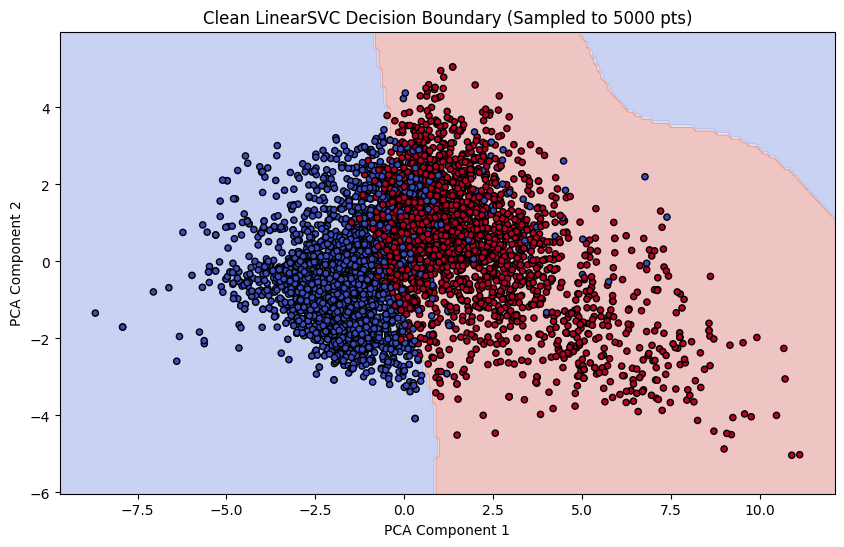

In [22]:
# 5. Decision Boundary Visualization
def plot_svm_2d(model, X, y, title, subset_size=5000):
    # 1. Sample the data for visualization (Crucial for 18M rows!)
    if len(X) > subset_size:
        # Use a random subset to keep the plot responsive
        indices = np.random.choice(len(X), subset_size, replace=False)
        X_sample = X.iloc[indices] if hasattr(X, 'iloc') else X[indices]
        y_sample = y.iloc[indices] if hasattr(y, 'iloc') else y[indices]
    else:
        X_sample, y_sample = X, y

    # 2. Transform the sampled data through your pipeline's preprocessor
    # This uses the 'remaining_numeric' and 'remaining_categorical' logic from Step 3
    X_transformed = model.named_steps['preprocessor'].transform(X_sample)
    
    # 3. Reduce to 2D using PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_transformed)
    
    # 4. Fit a small RBF SVC on the 2D plane just for the visual boundary
    # We use a subset because RBF is O(n^2)
    vis_svc = SVC(kernel='rbf', C=1.0).fit(X_pca, y_sample)
    
    # 5. Create a mesh grid
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    
    # 6. Predict and Plot
    Z = vis_svc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap=plt.cm.coolwarm, edgecolors='k', s=20)
    plt.title(f"{title} (Sampled to {subset_size} pts)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

# Fit on full data (LinearSVC handles this)
svm_pipeline.fit(X, y)

# Visualize on a representative sample
plot_svm_2d(svm_pipeline, X, y, "Clean LinearSVC Decision Boundary")

Grid Search Optimization

In [23]:
# 1. Grid Search Optimization (Sampled to handle the 18M row scale)
# We sample 50,000-100,000 rows for the Grid Search to find best params efficiently
X_train_sub, _, y_train_sub, _ = train_test_split(X, y, train_size=100000, stratify=y, random_state=42)

param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__max_iter": [5000] # Ensuring convergence
}

# n_jobs=-1 uses all CPU cores
grid_search = GridSearchCV(svm_pipeline, param_grid, cv=3, n_jobs=-1) 
grid_search.fit(X_train_sub, y_train_sub)
best_model = grid_search.best_estimator_

# 2. Performance Comparison (on a larger validation set)
# Using 500k rows for the final report to ensure the performance holds at scale
X_val, _, y_val, _ = train_test_split(X, y, train_size=500000, stratify=y, random_state=42)

y_pred_base = cross_val_predict(svm_pipeline, X_val, y_val, cv=3)
y_pred_opt = cross_val_predict(best_model, X_val, y_val, cv=3)

print("--- Baseline Report (LinearSVC) ---")
print(classification_report(y_val, y_pred_base))
print(f"\n--- Optimized Report (Best Params: {grid_search.best_params_}) ---")
print(classification_report(y_val, y_pred_opt))

--- Baseline Report (LinearSVC) ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    261559
           1       0.98      0.98      0.98    238441

    accuracy                           0.98    500000
   macro avg       0.98      0.98      0.98    500000
weighted avg       0.98      0.98      0.98    500000


--- Optimized Report (Best Params: {'classifier__C': 1, 'classifier__max_iter': 5000}) ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    261559
           1       0.98      0.98      0.98    238441

    accuracy                           0.98    500000
   macro avg       0.98      0.98      0.98    500000
weighted avg       0.98      0.98      0.98    500000



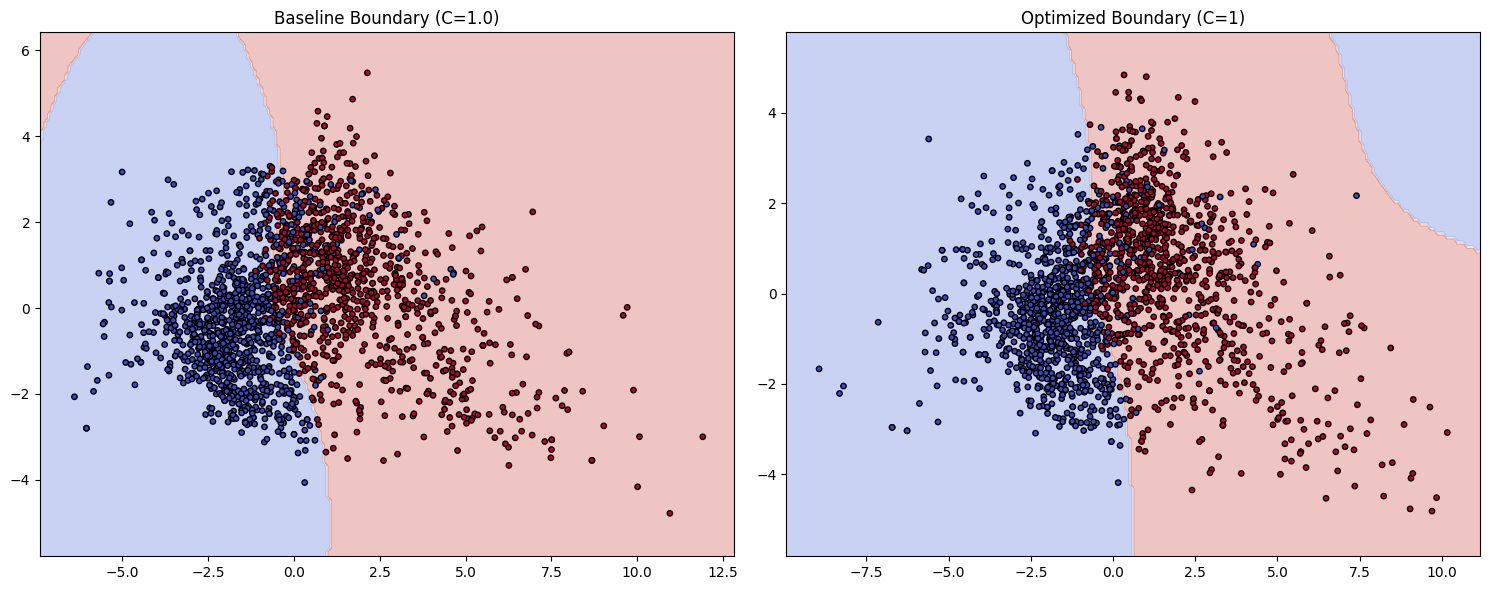

In [24]:
# 3. Side-by-Side Visualization (using the sampling function logic)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

def draw_boundary_optimized(ax, model, X, y, title, subset_size=2000):
    # Sample specifically for the plot
    idx = np.random.choice(len(X), subset_size, replace=False)
    X_sample, y_sample = X.iloc[idx], y.iloc[idx]
    
    X_trans = model.named_steps['preprocessor'].transform(X_sample)
    X_pca = PCA(n_components=2).fit_transform(X_trans)
    
    # We still use RBF SVC for the visualization to show the decision 'cloud'
    # even though the underlying model is LinearSVC
    vis_svc = SVC(kernel='rbf', C=model.named_steps['classifier'].C).fit(X_pca, y_sample)
    
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = vis_svc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap=plt.cm.coolwarm, edgecolors='k', s=15)
    ax.set_title(title)

draw_boundary_optimized(ax1, svm_pipeline, X, y, "Baseline Boundary (C=1.0)")
draw_boundary_optimized(ax2, best_model, X, y, f"Optimized Boundary (C={grid_search.best_params_['classifier__C']})")
plt.tight_layout()
plt.show()

SVM with ROI

In [ ]:
# 1. Load and Merge Data
# hpsa_df = pd.read_csv("hpsa_data.csv")
# mc_df = pd.read_csv("monte_carlo_results.csv")
# roi_df = pd.read_csv("roi_by_county.csv")
df = hpsa_df.merge(monte_df, on="geoid").merge(roi_df, on="geoid")

In [ ]:
# CURRENTLY THROWS ERROR, MISSING VALUE SOMEWHERE IN FINANCAL

# 2. Define Target Label
high_need_cats = [1, 3]
# Ensure we only pick mean columns from the original monte_carlo set
reduction_cols = [col for col in df.columns if "_mean" in col and col not in roi_df.columns]
df["avg_reduction"] = df[reduction_cols].mean(axis=1)
median_reduction = df["avg_reduction"].median()

df["target"] = 0
df.loc[(df["hpsa_need_category"].isin(high_need_cats)) & 
       (df["avg_reduction"] > median_reduction), "target"] = 1

# 3. Setup Pipeline (Leakage Fixed)
# We also drop metadata from roi_df (county, state) that shouldn't be features
metadata_cols = ["geoid", "county", "state"]
leakage_cols = ["target", "avg_reduction", "hpsa_need_category"] + reduction_cols
X = df.drop(columns=leakage_cols + metadata_cols)
y = df["target"]

# Dynamically find numeric and categorical columns
remaining_numeric = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
remaining_categorical = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), remaining_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), remaining_categorical)
])

# kernel = 'rbf' is non-linear (might be better but takes too long)
# svm_pipeline = Pipeline([
#     ("preprocessor", preprocessor),
#     ("classifier", SVC(kernel="rbf", C=1.0))
# ])

# Optimized for Speed with LinearSVC
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LinearSVC(C=1.0, dual=False, max_iter=10000))
])

# 4. Reporting
# Using StratifiedKFold to handle the 18M+ rows efficiently
y_pred = cross_val_predict(svm_pipeline, X, y, cv=StratifiedKFold(5))
print("--- Baseline LinearSVC Report (Including ROI Data) ---")
print(classification_report(y, y_pred, target_names=['Bad (0)', 'Good (1)']))

In [ ]:
# Ensure X and y are reset from the merge
svm_pipeline.fit(X, y)

# 5. Decision Boundary Visualization
def plot_svm_2d(model, X, y, title, subset_size=5000):
    # Sample the data - .iloc is used to ensure we handle the 18M rows correctly
    if len(X) > subset_size:
        indices = np.random.choice(len(X), subset_size, replace=False)
        X_sample = X.iloc[indices]
        y_sample = y.iloc[indices]
    else:
        X_sample, y_sample = X, y

    # Transform using the updated preprocessor (now including ROI numeric data)
    X_transformed = model.named_steps['preprocessor'].transform(X_sample)
    
    # PCA reduction to 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_transformed)
    
    # Fit visualizer on the 2D plane
    vis_svc = SVC(kernel='rbf', C=1.0).fit(X_pca, y_sample)
    
    # Create mesh
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    
    Z = vis_svc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap=plt.cm.coolwarm, edgecolors='k', s=20)
    plt.title(f"{title} with ROI Data\n(Sampled to {subset_size} pts)")
    plt.xlabel("PCA Component 1 (Variance: {:.2f}%)".format(pca.explained_variance_ratio_[0]*100))
    plt.ylabel("PCA Component 2 (Variance: {:.2f}%)".format(pca.explained_variance_ratio_[1]*100))
    plt.show()

# Run the visualization
plot_svm_2d(svm_pipeline, X, y, "LinearSVC Decision Boundary")
# Visualize on a representative sample
plot_svm_2d(svm_pipeline, X, y, "Clean LinearSVC Decision Boundary")